# Análise de Espécies de Aves

Neste notebook, vamos analisar um dataset de características de aves, com o objetivo de classificar a sua espécie. Iremos explorar os dados, visualizá-los e treinar modelos de Machine Learning para prever a espécia das aves.

## 1. Importação de Bibliotecas

Começamos por importar a biblioteca `pandas` para manipulação de dados.

In [ ]:
import pandas as pd

## 2. Carregamento e Exploração dos Dados

Carregamos o ficheiro `hiv_balanced_descriptors.csv` e removemos as colunas `Drug_ID` e `SMILES`, que não são relevantes para a modelação numérica. De seguida, visualizamos as primeiras linhas e estatísticas descritivas do dataset.

In [24]:
df = pd.read_csv(open('bird_species_subset.csv',mode='r'))
cols=['ColorVision','NocturnalVision']
df[cols] = df[cols].replace({'Yes':1,'No':0})

df.head()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15156\2274172884.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].replace({'Yes':1,'No':0})


,BodyLength,Wingspan,Weight,PlumageColorHead,PlumageColorBack,PlumageColorBelly,PlumageColorWings,PlumageColorTail,BeakLength,BeakWidth,...,SeedDispersalRole,InterspecificInteraction,IntraspecificInteraction,LearningAbility,ToolUse,ParentalCareLevel,BathingBehavior,GroomingBehavior,FlightSpeed,SpeciesClass
0,6.534,4.072,4.293,7.708,2.436,9.538,5.113,6.028,2.710,9.015,...,4.074,2.507,4.511,9.528,8.802,3.759,6.101,3.340,6.071,2
1,2.639,2.624,8.962,6.319,6.330,7.549,3.139,7.163,4.628,6.653,...,5.366,2.987,7.695,7.575,1.394,7.137,0.270,9.548,8.011,3
2,2.535,6.666,0.240,7.834,2.922,4.281,7.711,1.326,3.332,0.566,...,5.709,3.039,5.403,1.983,6.058,5.473,5.919,4.092,5.759,1
3,6.269,7.994,1.732,7.261,6.289,4.672,2.647,6.147,7.287,6.420,...,9.873,8.219,3.017,1.789,5.533,9.014,4.685,5.877,9.617,1
4,7.653,5.399,6.889,3.842,8.725,9.066,9.043,8.459,3.110,9.144,...,8.173,2.955,8.042,1.771,1.583,9.255,6.477,3.492,3.503,1


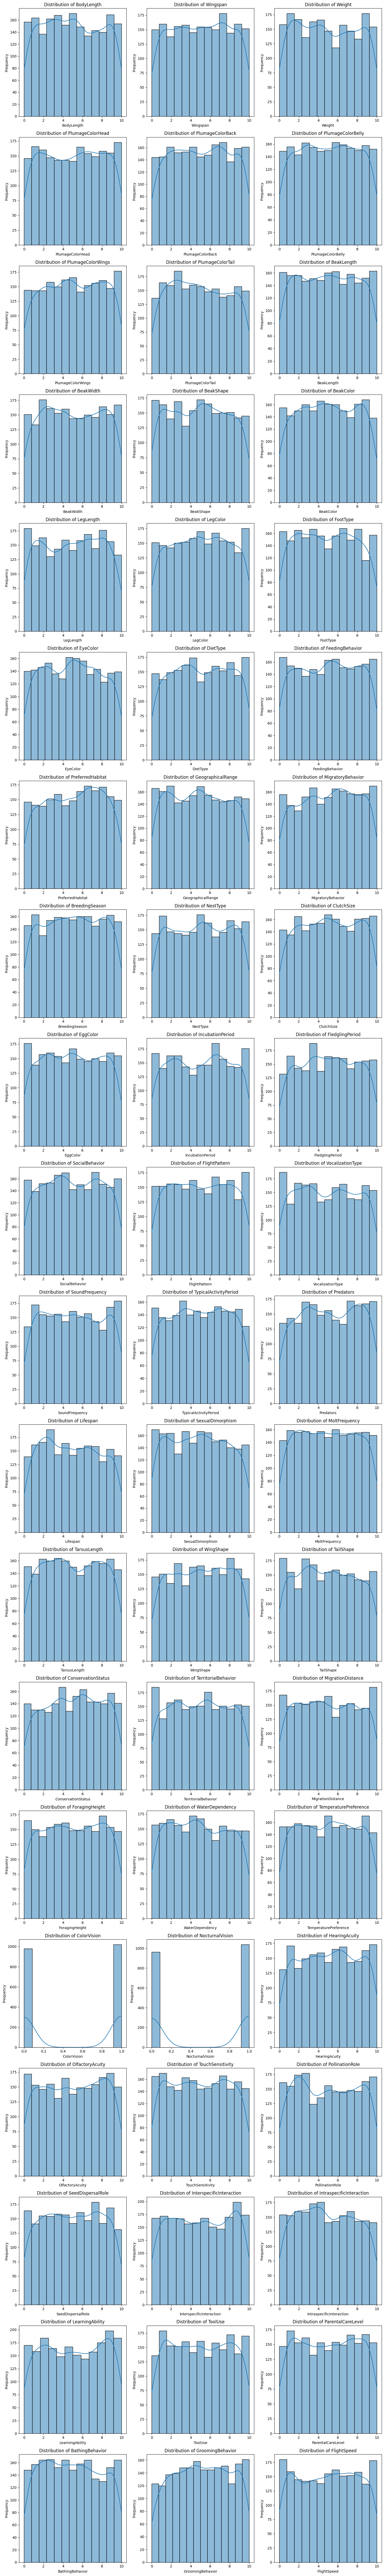

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
numerical_cols = ['BodyLength','Wingspan','Weight','PlumageColorHead','PlumageColorBack','PlumageColorBelly','PlumageColorWings','PlumageColorTail','BeakLength','BeakWidth','BeakShape','BeakColor','LegLength','LegColor','FootType','EyeColor','DietType','FeedingBehavior','PreferredHabitat','GeographicalRange','MigratoryBehavior','BreedingSeason','NestType','ClutchSize','EggColor','IncubationPeriod','FledglingPeriod','SocialBehavior','FlightPattern','VocalizationType','SoundFrequency','TypicalActivityPeriod','Predators','Lifespan','SexualDimorphism','MoltFrequency','TarsusLength','WingShape','TailShape','ConservationStatus','TerritorialBehavior','MigrationDistance','ForagingHeight','WaterDependency','TemperaturePreference','ColorVision','NocturnalVision','HearingAcuity','OlfactoryAcuity','TouchSensitivity','PollinationRole','SeedDispersalRole','InterspecificInteraction','IntraspecificInteraction','LearningAbility','ToolUse','ParentalCareLevel','BathingBehavior','GroomingBehavior','FlightSpeed']
activity = numerical_cols + ['SpeciesClass']
n_cols = 3
n_rows = (len(numerical_cols)+n_cols-1) // n_cols

plt.figure(figsize=(15,5*n_rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1) # Arrange plots in a 3x3 grid
    sns.histplot(df[col], kde=True) # Use histplot for distribution
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

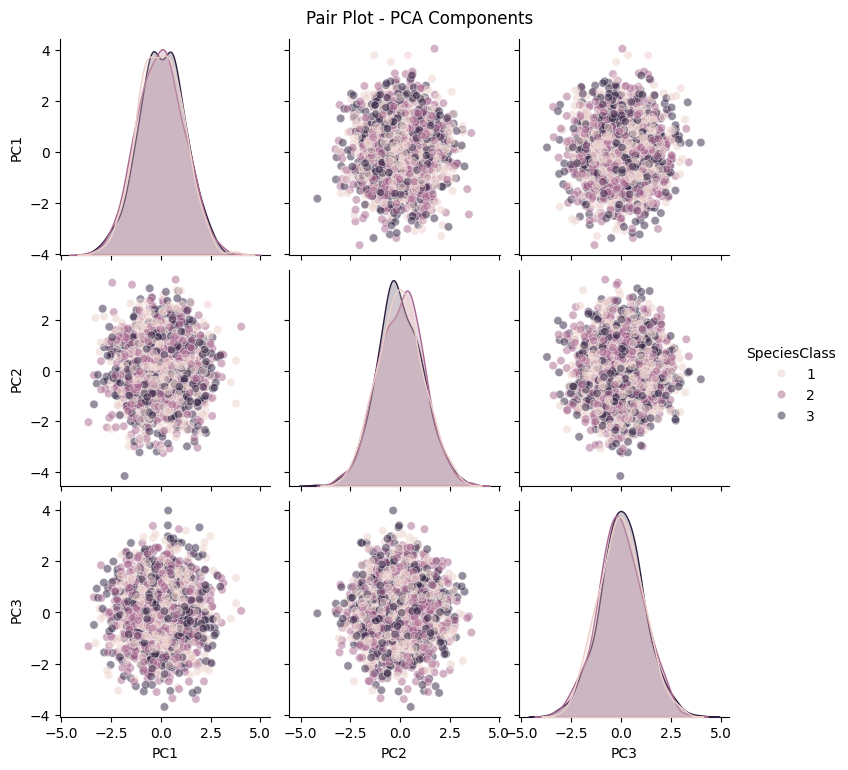

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(df[numerical_cols])
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['SpeciesClass'] = df['SpeciesClass'].values

sns.pairplot(pca_df, hue='SpeciesClass', diag_kind='kde',plot_kws=dict(alpha=0.5))
plt.suptitle('Pair Plot - PCA Components', y=1.02)
plt.show()

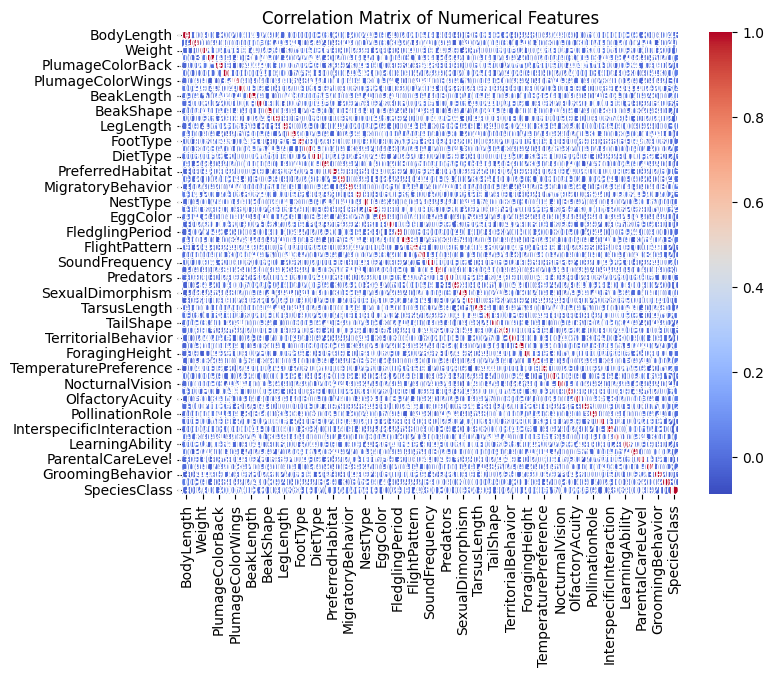

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[activity].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[numerical_cols]
y = df['SpeciesClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y,
                                                    shuffle=True)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nApplying StandardScaler to training data...")
# Instantiate a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the X_train data and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

print("Scaling of training data complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Data splitting complete.
X_train shape: (1600, 60)
X_test shape: (400, 60)
y_train shape: (1600,)
y_test shape: (400,)

Applying StandardScaler to training data...
Scaling of training data complete.
X_train_scaled shape: (1600, 60)


In [29]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

print("Starting Nested Cross-Validation with Pipeline...")

# 3. Define the parameter grid for K-Nearest Neighbors (KNN)
# Note: parameters prefixed with 'knn__' because 'knn' is a step in the pipeline
knn_param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'], 
    'knn__metric': ['euclidean', 'manhattan']
}

# 4. Define the parameter grid for Gaussian Naive Bayes (NB)
# Note: parameters prefixed with 'nb__' because 'nb' is a step in the pipeline
nb_param_grid = {
    'nb__var_smoothing': np.logspace(start=0, stop=-9, num=100, base=10)
}

# 5. Initialize an outer_cv object using StratifiedKFold
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6. Initialize empty lists to store the cross-validation scores
knn_outer_scores = []
nb_outer_scores = []

# 7. Loop through the outer folds (data is NOT pre-scaled)
for train_idx, test_idx in outer_cv.split(X_train, y_train):
    X_outer_train, X_outer_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_outer_train, y_outer_test = y_train.iloc[train_idx], y_train.iloc[test_idx]

    # a. Inside the loop, define an inner_cv object
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # b. For KNN with Pipeline:
    # i. Create a Pipeline with StandardScaler and KNeighborsClassifier
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])
    # ii. Create a GridSearchCV object with the pipeline
    knn_grid_search = GridSearchCV(knn_pipeline, knn_param_grid, cv=inner_cv, scoring='accuracy')
    # iii. Fit the GridSearchCV object on the outer training fold
    knn_grid_search.fit(X_outer_train, y_outer_train)
    # iv. Evaluate the best_estimator_ on the outer test fold
    knn_best_model = knn_grid_search.best_estimator_
    knn_pred = knn_best_model.predict(X_outer_test)
    knn_outer_scores.append(accuracy_score(y_outer_test, knn_pred))

    # c. For Naive Bayes with Pipeline:
    # i. Create a Pipeline with StandardScaler and GaussianNB
    nb_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('nb', GaussianNB())
    ])
    # ii. Create a GridSearchCV object with the pipeline
    nb_grid_search = GridSearchCV(nb_pipeline, nb_param_grid, cv=inner_cv, scoring='accuracy')
    # iii. Fit the GridSearchCV object on the outer training fold
    nb_grid_search.fit(X_outer_train, y_outer_train)
    # iv. Evaluate the best_estimator_ on the outer test fold
    nb_best_model = nb_grid_search.best_estimator_
    nb_pred = nb_best_model.predict(X_outer_test)
    nb_outer_scores.append(accuracy_score(y_outer_test, nb_pred))

# 8. Print the mean and standard deviation of the cross-validation scores
print("\nNested Cross-Validation Results with Pipeline:")
print(f"KNN - Mean Accuracy: {np.mean(knn_outer_scores):.4f} (+/- {np.std(knn_outer_scores):.4f})")
print(f"Naive Bayes - Mean Accuracy: {np.mean(nb_outer_scores):.4f} (+/- {np.std(nb_outer_scores):.4f})")

Starting Nested Cross-Validation with Pipeline...

Nested Cross-Validation Results with Pipeline:
KNN - Mean Accuracy: 0.3219 (+/- 0.0190)
Naive Bayes - Mean Accuracy: 0.3375 (+/- 0.0267)


In [30]:
# Re-run GridSearchCV for Naive Bayes on the entire X_train and y_train dataset
print("Training best Naive Bayes model with Pipeline...")
nb_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])
nb_grid_search_final = GridSearchCV(nb_pipeline_final, nb_param_grid, cv=inner_cv, scoring='accuracy')
nb_grid_search_final.fit(X_train, y_train)
best_nb_model = nb_grid_search_final.best_estimator_
print(f"Best NB parameters: {nb_grid_search_final.best_params_}")
print(f"Best NB accuracy: {nb_grid_search_final.best_score_:.4f}")

# Re-run GridSearchCV for KNN on the entire X_train and y_train dataset
print("\nTraining best KNN model with Pipeline...")
knn_pipeline_final = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
knn_grid_search_final = GridSearchCV(knn_pipeline_final, knn_param_grid, cv=inner_cv, scoring='accuracy')
knn_grid_search_final.fit(X_train, y_train)
best_knn_model = knn_grid_search_final.best_estimator_
print(f"Best KNN parameters: {knn_grid_search_final.best_params_}")
print(f"Best KNN accuracy: {knn_grid_search_final.best_score_:.4f}")

Training best Naive Bayes model with Pipeline...
Best NB parameters: {'nb__var_smoothing': np.float64(0.8111308307896871)}
Best NB accuracy: 0.3481

Training best KNN model with Pipeline...
Best KNN parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Best KNN accuracy: 0.3500


In [31]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

# IMPORTANT: Make predictions directly with pipeline (no pre-scaling needed!)
# The pipeline contains its own scaler fitted during training

# KNN predictions
print("\n🔵 KNN Model Predictions:")
knn_pred_test = best_knn_model.predict(X_test)  # X_test NOT scaled
knn_accuracy = accuracy_score(y_test, knn_pred_test)
print(f"KNN Test Set Accuracy: {knn_accuracy:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, knn_pred_test))
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred_test))

# Naive Bayes predictions
print("\n🟡 Naive Bayes Model Predictions:")
nb_pred_test = best_nb_model.predict(X_test)  # X_test NOT scaled
nb_accuracy = accuracy_score(y_test, nb_pred_test)
print(f"Naive Bayes Test Set Accuracy: {nb_accuracy:.4f}")
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_pred_test))
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, nb_pred_test))

# Comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"KNN Accuracy:          {knn_accuracy:.4f}")
print(f"Naive Bayes Accuracy:  {nb_accuracy:.4f}")
print(f"Better Model:          {'KNN' if knn_accuracy > nb_accuracy else 'Naive Bayes'}")


FINAL EVALUATION ON TEST SET

🔵 KNN Model Predictions:
KNN Test Set Accuracy: 0.3300

KNN Classification Report:
              precision    recall  f1-score   support

           1       0.31      0.28      0.29       134
           2       0.35      0.37      0.36       133
           3       0.33      0.35      0.34       133

    accuracy                           0.33       400
   macro avg       0.33      0.33      0.33       400
weighted avg       0.33      0.33      0.33       400

KNN Confusion Matrix:
[[37 48 49]
 [39 49 45]
 [44 43 46]]

🟡 Naive Bayes Model Predictions:
Naive Bayes Test Set Accuracy: 0.3425

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           1       0.29      0.16      0.21       134
           2       0.39      0.47      0.42       133
           3       0.32      0.40      0.36       133

    accuracy                           0.34       400
   macro avg       0.33      0.34      0.33       400
weighted avg


Confusion Matrix for KNN on Scaled Test Set:


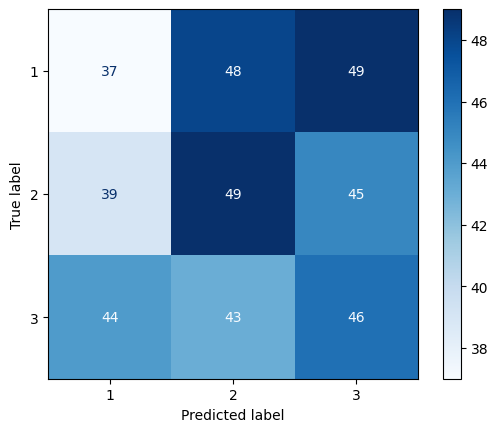

In [32]:
#plot confusion matrix of KNN
from sklearn.metrics import ConfusionMatrixDisplay
#display
print("\nConfusion Matrix for KNN on Scaled Test Set:")
knn_cm = ConfusionMatrixDisplay.from_predictions(y_test, knn_pred_test, display_labels=best_knn_model.classes_, cmap='Blues')